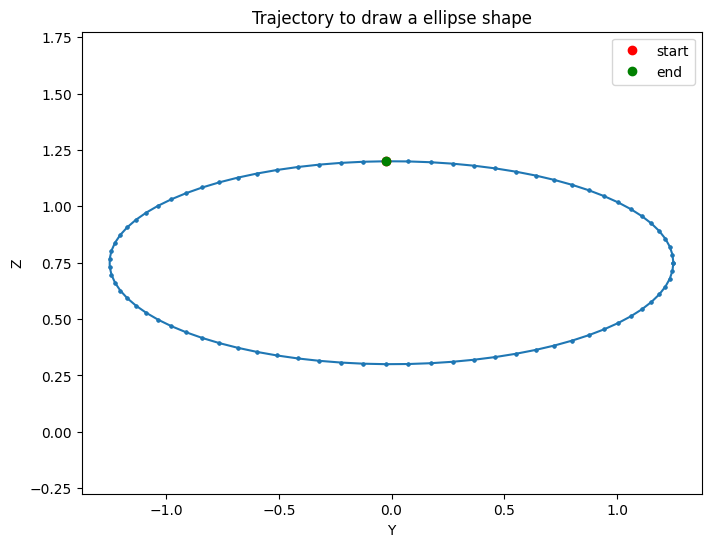

Shape of trajectory: (178, 3)


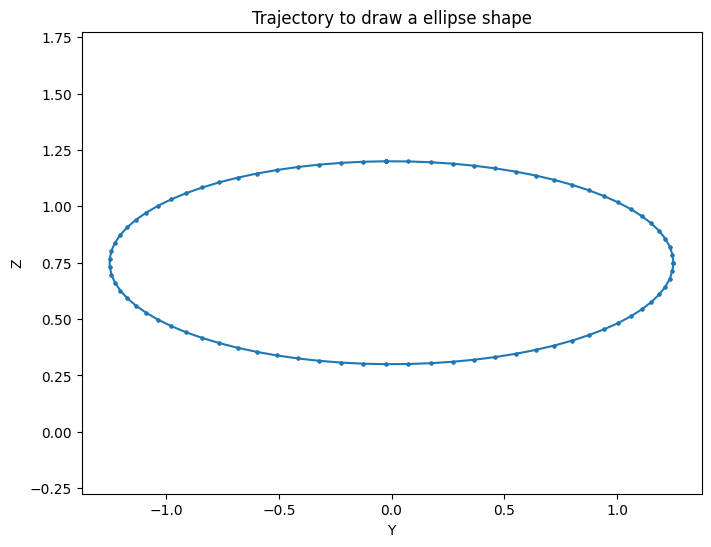

In [6]:
"Simple shape goal trajectory generator"

import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# select the shape
shape_type: str = "ellipse"  # Options: "heart", "ellipse", "infinity"

# fixed x-coordinate
x_fixed = 1.1

# parameter t (more points for smoother/slower trajectory)
t = np.linspace(0, 2 * np.pi, 80)

# depending on shape_type, define y and z
if shape_type == "heart":
    y = 16 * np.sin(t) ** 3
    z = 13 * np.cos(t) - 5 * np.cos(2 * t) - 2 * np.cos(3 * t) - np.cos(4 * t)
elif shape_type == "ellipse":
    a = 1
    b = 0.5
    y = a * np.cos(t)
    z = b * np.sin(t)
elif shape_type == "infinity":
    y = np.sin(t)
    z = np.sin(2 * t)
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

# find the index where y is closest to zero
start_idx = np.argmin(np.abs(y))

# rotate y and z arrays so that y starts from the point closest to y=0
y = np.roll(y, -start_idx)
z = np.roll(z, -start_idx)

# normalize the coordinates and scale to desired ranges
desired_range_y = [-1.25, 1.25]
desired_range_z = [0.3, 1.2]

y_min, y_max = y.min(), y.max()
z_min, z_max = z.min(), z.max()
y_normalized = (y - y_min) / (y_max - y_min)
y_scaled = y_normalized * (desired_range_y[1] - desired_range_y[0]) + desired_range_y[0]
z_normalized = (z - z_min) / (z_max - z_min)
z_scaled = z_normalized * (desired_range_z[1] - desired_range_z[0]) + desired_range_z[0]

# ensure the trajectory is closed by appending the starting point at the end if necessary
if y_scaled[0] != y_scaled[-1] or z_scaled[0] != z_scaled[-1]:
    # append the starting point to the end
    y_scaled = np.append(y_scaled, y_scaled[0])
    z_scaled = np.append(z_scaled, z_scaled[0])
# repeat first point n times
repeat_first_point_times = 5
y_scaled = np.insert(y_scaled, 0, [y_scaled[0]] * (repeat_first_point_times - 1))
z_scaled = np.insert(z_scaled, 0, [z_scaled[0]] * (repeat_first_point_times - 1))

# repeat the last point n times
repeat_last_point_times = 5
y_scaled = np.append(y_scaled, [y_scaled[-1]] * (repeat_last_point_times - 1))
z_scaled = np.append(z_scaled, [z_scaled[-1]] * (repeat_last_point_times - 1))

# repeat each point (slows down trajectory)
repeat_times = 2
y_repeated = np.repeat(y_scaled, repeat_times)
z_repeated = np.repeat(z_scaled, repeat_times)

# fixed x-coordinate array
x_points = np.full_like(y_repeated, x_fixed)

# plot the trajectory
plt.figure(figsize=(8, 6))
plt.plot(y_repeated, z_repeated, '-o', markersize=2)
# highlight start and end points
plt.plot(y_repeated[0], z_repeated[0], 'ro', label='start')
plt.plot(y_repeated[-1], z_repeated[-1], 'go', label='end')
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.legend()
plt.show()

# save trajectory as array
trajectory = np.column_stack((x_points, y_repeated, z_repeated))
print("Shape of trajectory:", trajectory.shape)
dir_name = f"goal_traj/{shape_type}_v0_goal_trajectory.pkl"
# if it exists, append version
if os.path.exists(dir_name):
    version = 1
    while os.path.exists(dir_name):
        version += 1
        dir_name = f"goal_traj/{shape_type}_v{version}_goal_trajectory.pkl"
else:
    version = 0
    dir_name = f"goal_traj/{shape_type}_v{version}_goal_trajectory.pkl"

with open(dir_name, "wb") as f:
    pickle.dump(trajectory, f)

# import and plot the trajectory to check
with open(dir_name, "rb") as f:
    trajectory = pickle.load(f)

plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 1], trajectory[:, 2], '-o', markersize=2)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title(f'Trajectory to draw a {shape_type} shape')
plt.axis('equal')
plt.show()

Initial lengths - x: 100, y: 100, z: 100
After pause points - x: 118, y: 118, z: 118
After repeating points - x: 236, y: 236, z: 236
x: max: 4.0, min: 1.0
y: max: 0.7, min: -0.6002997351274055
z: max: 1.2507772058313538, min: 0.0495642428462002
Plotting lengths - x: 236, y: 236, z: 236


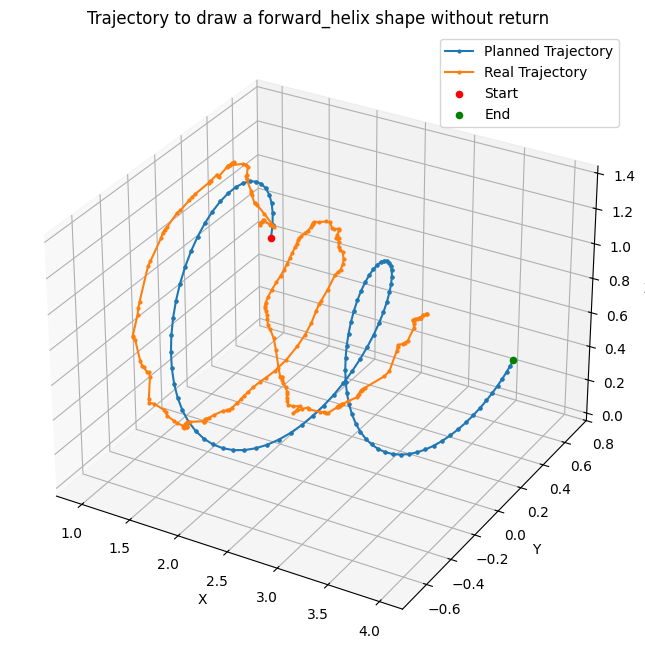

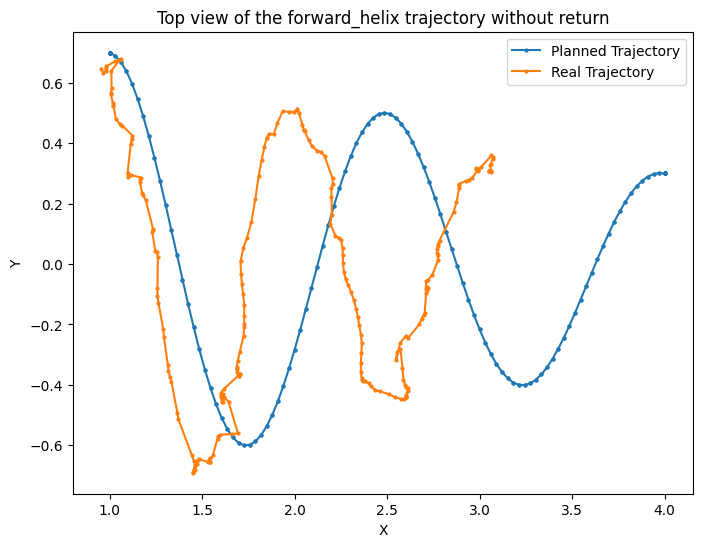

Shape of trajectory: (236, 3)
Plotting lengths - x: 236, y: 236, z: 236


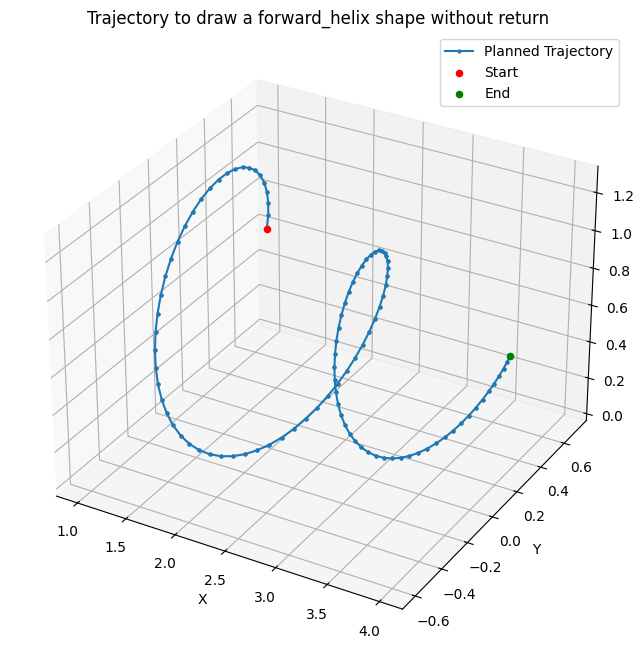

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal

def generate_slalom():
    """Generates a slalom trajectory with parameters set inside the function."""
    num_points = 100
    x_min, x_max = 1.0, 4.0
    z_min, z_max = 0.4, 0.8
    num_oscillations = 3
    y_amplitude = 0.3

    t = np.linspace(0, 4 * np.pi, num_points)
    x = np.linspace(x_min, x_max, num_points)
    y = y_amplitude * np.sin(num_oscillations * t)
    z = np.linspace(z_min, z_max, num_points)
    return x, y, z


def generate_zigzag():
    """Generates a zigzag trajectory with parameters set inside the function."""
    num_points = 100
    x_min, x_max = 1.0, 4.0
    z_min, z_max = 0.4, 0.8
    num_zigs = 5
    y_amplitude = 1.0

    t = np.linspace(0, 4 * np.pi, num_points)
    x = np.linspace(x_min, x_max, num_points)
    y = y_amplitude * signal.sawtooth(num_zigs * t, 0.5)
    z = np.linspace(z_min, z_max, num_points)
    return x, y, z


def generate_helix():
    """Generates a conical helix trajectory with parameters set inside the function."""
    num_points = 100
    x_min, x_max = 1.0, 4.0
    z_min, z_max = 0.4, 0.8
    helix_radius_start = 0.5
    helix_radius_end = 0.1
    helix_turns = 3

    theta = np.linspace(0, helix_turns * 2 * np.pi, num_points)
    z = np.linspace(z_min, z_max, num_points)
    radius = np.linspace(helix_radius_start, helix_radius_end, num_points)
    x_center = (x_min + x_max) / 2
    y_center = 0.0
    x = x_center + radius * np.cos(theta)
    y = y_center + radius * np.sin(theta)
    return x, y, z


def generate_forward_helix():
    """Generates a forward helix trajectory with parameters set inside the function."""
    num_points = 100
    x_min, x_max = 1.0, 4.0
    z_min, z_max = 0.4, 0.8
    helix_radius_start = 0.7
    helix_radius_end = 0.3
    helix_turns = 2

    x = np.linspace(x_min, x_max, num_points)
    theta = np.linspace(0, helix_turns * 2 * np.pi, num_points)
    radius = np.linspace(helix_radius_start, helix_radius_end, num_points)
    y_center = 0.0
    z_center = (z_min + z_max) / 2
    y = y_center + radius * np.cos(theta)
    z = z_center + radius * np.sin(theta)
    return x, y, z


def generate_line_touching():
    """
    Generates the specified trajectory with parameters set inside the function.
    This includes inclined movements and direct transitions between y positions.
    """
    num_touches = 3
    x_min, x_max = 1.0, 4.0
    z_min, z_max = 0.4, 0.8
    y_min, y_max = -0.8, 0.8  # Desired y range for touch points
    delta_x = 0.1  # Adjust this value for the incline

    y_positions = np.linspace(y_min, y_max, num_touches)
    x_list, y_list, z_list = [], [], []

    for i in range(num_touches):
        y_current = y_positions[i]
        if i + 1 < num_touches:
            y_next = y_positions[i + 1]
        else:
            y_next = None  # Last y position

        # Define the sequence of key points with inclines
        x_sequence = [
            x_max - delta_x,  # Start of incline at z_max
            x_max,            # Touch the ground at x_max
            x_max - delta_x,  # Incline back up
            x_min + delta_x,  # Move to x_min + delta_x at z_max
            x_min,            # Touch the ground at x_min
            x_min + delta_x,  # Incline back up
        ]
        y_sequence = [y_current] * len(x_sequence)
        z_sequence = [
            z_max, z_min, z_max, z_max, z_min, z_max
        ]

        # Append the sequence to the lists
        x_list.extend(x_sequence)
        y_list.extend(y_sequence)
        z_list.extend(z_sequence)

        # If there is a next y, move directly to (x_max - delta_x, y_next, z_max)
        if y_next is not None:
            x_list.append(x_max - delta_x)
            y_list.append(y_next)
            z_list.append(z_max)
        else:
            # No next y, end at current position
            pass

    # Convert lists to arrays
    x = np.array(x_list)
    y = np.array(y_list)
    z = np.array(z_list)

    return x, y, z


def normalize_and_scale(data, desired_range):
    """Normalizes and scales data to a desired range."""
    data_min, data_max = data.min(), data.max()
    if data_max - data_min != 0:
        data_normalized = (data - data_min) / (data_max - data_min)
        data_scaled = data_normalized * (desired_range[1] - desired_range[0]) + desired_range[0]
    else:
        data_scaled = data
    return data_scaled


def add_pause_points(x, y, z, repeat_first_point_times, repeat_last_point_times):
    """Adds pauses at the start and end of the trajectory."""
    x = np.insert(x, 0, [x[0]] * (repeat_first_point_times - 1))
    y = np.insert(y, 0, [y[0]] * (repeat_first_point_times - 1))
    z = np.insert(z, 0, [z[0]] * (repeat_first_point_times - 1))
    x = np.append(x, [x[-1]] * (repeat_last_point_times - 1))
    y = np.append(y, [y[-1]] * (repeat_last_point_times - 1))
    z = np.append(z, [z[-1]] * (repeat_last_point_times - 1))
    return x, y, z


def repeat_each_point(x, y, z, repeat_times):
    """Repeats each point to slow down the trajectory."""
    x_repeated = np.repeat(x, repeat_times)
    y_repeated = np.repeat(y, repeat_times)
    z_repeated = np.repeat(z, repeat_times)
    return x_repeated, y_repeated, z_repeated


def add_reverse_trajectory(x, y, z):
    """Adds a reverse trajectory to return to the starting point."""
    x_back = x[::-1][1:]
    y_back = y[::-1][1:]
    z_back = z[::-1][1:]
    x_total = np.concatenate((x, x_back))
    y_total = np.concatenate((y, y_back))
    z_total = np.concatenate((z, z_back))
    return x_total, y_total, z_total


def plot_3d_trajectory(x, y, z, observations=None, reverse_trajectory=False, shape_type=''):
    """Plots the 3D trajectory."""
    # Ensure lengths are equal
    assert len(x) == len(y) == len(z), "x, y, z arrays must have the same length."
    print(f"Plotting lengths - x: {len(x)}, y: {len(y)}, z: {len(z)}")

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, '-o', markersize=2, label='Planned Trajectory')
    if observations is not None:
        ax.plot(observations[:, 7], observations[:, 8], observations[:, 9], '-o', markersize=2, label='Real Trajectory')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    title_suffix = "with return" if reverse_trajectory else "without return"
    ax.set_title(f'Trajectory to draw a {shape_type} shape {title_suffix}')
    ax.scatter(x[0], y[0], z[0], color='red', label='Start')
    ax.scatter(x[-1], y[-1], z[-1], color='green', label='End')
    ax.legend()
    plt.show()


def plot_2d_top_view(x, y, observations=None, reverse_trajectory=False, shape_type=''):
    """Plots the top view (2D) of the trajectory."""
    plt.figure(figsize=(8, 6))
    plt.plot(x, y, '-o', markersize=2, label='Planned Trajectory')
    if observations is not None:
        plt.plot(observations[:, 7], observations[:, 8], '-o', markersize=2, label='Real Trajectory')
    plt.xlabel('X')
    plt.ylabel('Y')
    title_suffix = "with return" if reverse_trajectory else "without return"
    plt.title(f'Top view of the {shape_type} trajectory {title_suffix}')
    plt.legend()
    plt.show()


# Main parameters (only for final processing steps)
shape_type = "forward_helix"  # Options: "slalom", "zigzag", "helix", "forward_helix", "line_touching"
tag = "_v2"  # Tag to differentiate between different versions
reverse_trajectory = False
save_trajectory = True
repeat_first_point_times = 10
repeat_last_point_times = 10
repeat_times = 2

# Generate the trajectory directly using the selected shape function
if shape_type == "slalom":
    x, y, z = generate_slalom()
elif shape_type == "zigzag":
    x, y, z = generate_zigzag()
elif shape_type == "helix":
    x, y, z = generate_helix()
elif shape_type == "forward_helix":
    x, y, z = generate_forward_helix()
elif shape_type == "line_touching":
    x, y, z = generate_line_touching()
else:
    raise ValueError(f"Unknown shape_type: {shape_type}")

print(f"Initial lengths - x: {len(x)}, y: {len(y)}, z: {len(z)}")

# Normalize z to desired range (if needed)
z_scaled = z  # No need to normalize since we define z explicitly

# For certain shapes, normalize x and y only if needed
if shape_type not in ["helix", "forward_helix", "line_touching"]:
    y_scaled = normalize_and_scale(y, [-0.3, 0.3])
    # Keep x as is or normalize if desired:
    # x_scaled = normalize_and_scale(x, [1.0, 4.0])  # if needed
    x_scaled = x
else:
    x_scaled = x
    y_scaled = y

# Add pauses at start and end
x_scaled, y_scaled, z_scaled = add_pause_points(
    x_scaled, y_scaled, z_scaled, repeat_first_point_times, repeat_last_point_times
)

print(f"After pause points - x: {len(x_scaled)}, y: {len(y_scaled)}, z: {len(z_scaled)}")

# Repeat each point
x_repeated, y_repeated, z_repeated = repeat_each_point(
    x_scaled, y_scaled, z_scaled, repeat_times
)

print(f"After repeating points - x: {len(x_repeated)}, y: {len(y_repeated)}, z: {len(z_repeated)}")

# Initialize total trajectory with forward path
x_total = x_repeated
y_total = y_repeated
z_total = z_repeated

# Add reverse trajectory if needed
if reverse_trajectory:
    x_total, y_total, z_total = add_reverse_trajectory(x_total, y_total, z_total)

# print max and mins for x,z,y
print(f"x: max: {max(x_total)}, min: {min(x_total)}")
print(f"y: max: {max(y_total)}, min: {min(y_total)}")
print(f"z: max: {max(z_total)}, min: {min(z_total)}")

# Load real robot trajectory (if available)
observations = None
try:
    file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v0/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_8000_137_forward_helix_v0_megxr1ty_v_v1/brax_transitions.pickle"
    with open(file, "rb") as f:
        data = pickle.load(f)
    observations = np.array([d.observation for d in data])[15:]
except Exception as e:
    print(f"Could not load real robot trajectory: {e}")

# Plot the trajectories
plot_3d_trajectory(x_total, y_total, z_total, observations, reverse_trajectory, shape_type)
plot_2d_top_view(x_total, y_total, observations, reverse_trajectory, shape_type)

# Save the trajectory if needed
if save_trajectory:
    trajectory = np.column_stack((x_total, y_total, z_total))
    print("Shape of trajectory:", trajectory.shape)
    with open(f"goal_traj/{shape_type}{tag}_goal_trajectory.pkl", "wb") as f:
        pickle.dump(trajectory, f)

    # Verify the saved trajectory
    with open(f"goal_traj/{shape_type}{tag}_goal_trajectory.pkl", "rb") as f:
        trajectory_loaded = pickle.load(f)
    plot_3d_trajectory(
        trajectory_loaded[:, 0], trajectory_loaded[:, 1], trajectory_loaded[:, 2],
        reverse_trajectory=reverse_trajectory, shape_type=shape_type
    )


Plotting lengths - x: 236, y: 236, z: 236


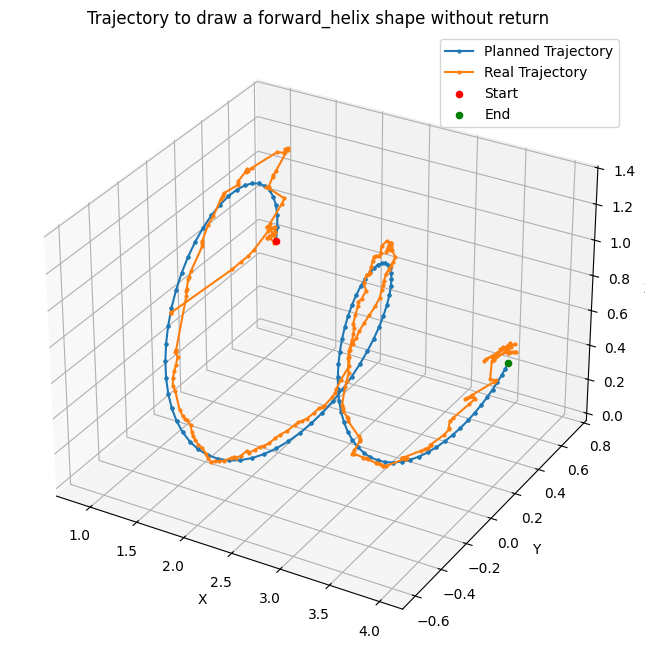

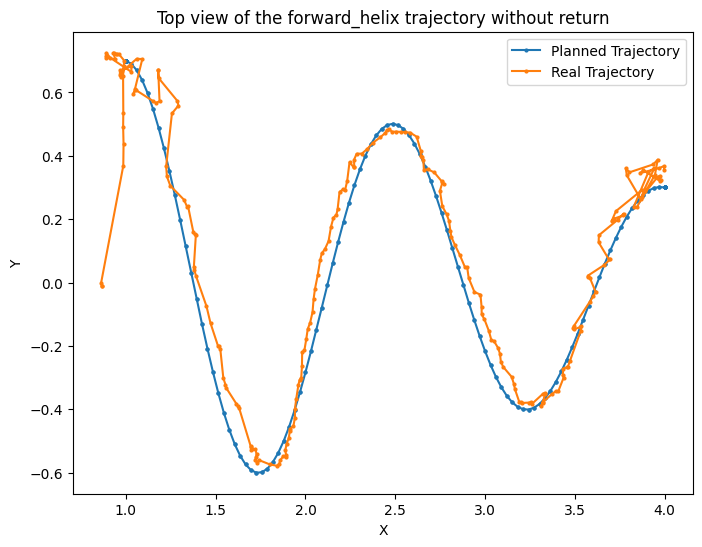

In [13]:
# Verify the saved trajectory

# real traj:
file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_5000_332_forward_helix_v2_4e5k4pn0_v/brax_transitions.pickle"
with open(file, "rb") as f:
    data = pickle.load(f)
observations = np.array([d.observation for d in data])

shape_type = "forward_helix"
tag = "_v2"
with open(f"goal_traj/{shape_type}{tag}_goal_trajectory.pkl", "rb") as f:
    trajectory_loaded = pickle.load(f)
plot_3d_trajectory(
    trajectory_loaded[:, 0], trajectory_loaded[:, 1], trajectory_loaded[:, 2],
    reverse_trajectory=reverse_trajectory, shape_type=shape_type, observations=observations
)
plot_2d_top_view(
    trajectory_loaded[:, 0], trajectory_loaded[:, 1], observations, reverse_trajectory, shape_type
)

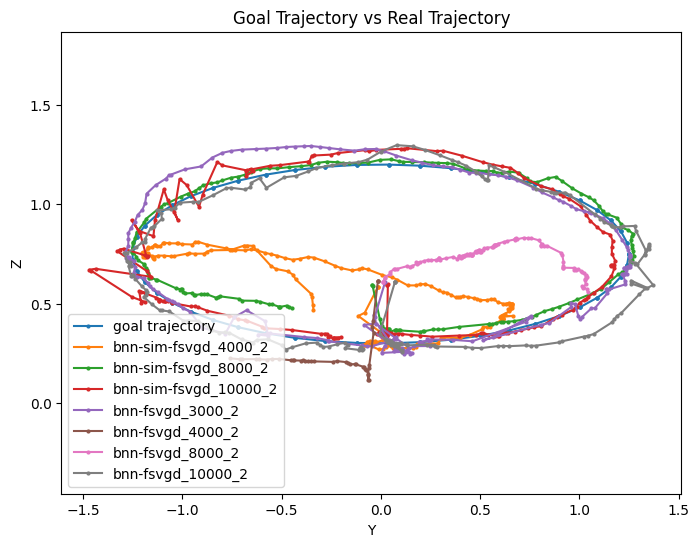

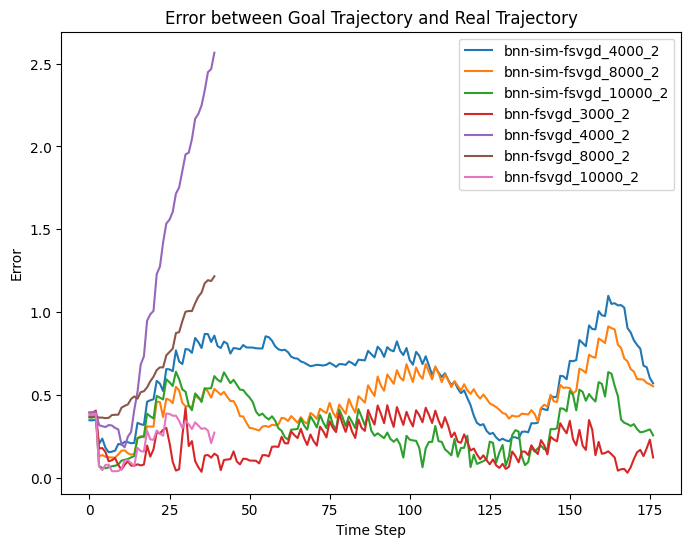

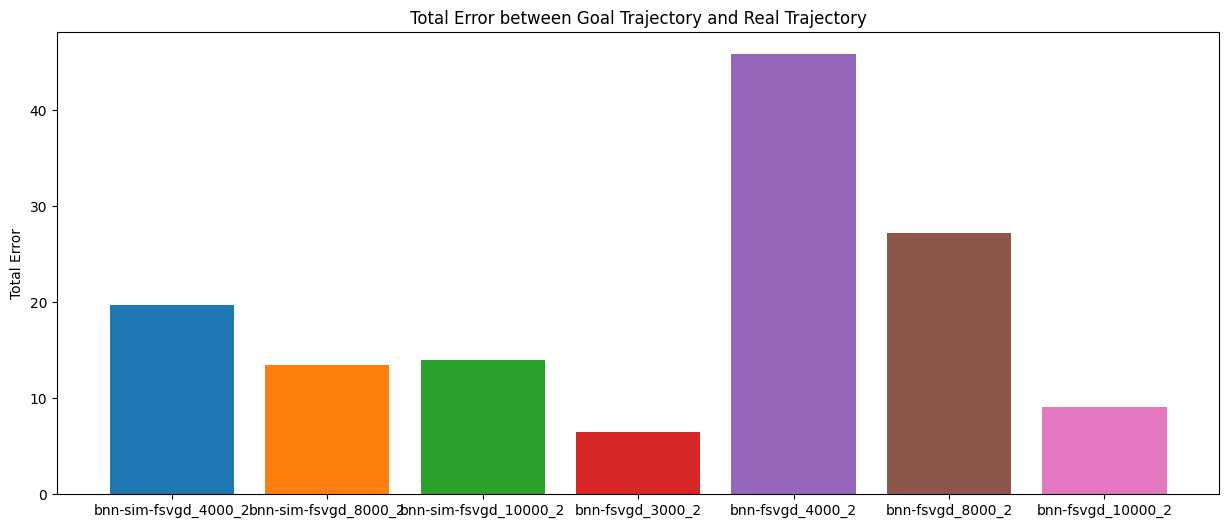

In [ ]:
"""Compare simple goal trajectory with real trajectory"""

import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load the goal trajectory
file = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/goal_traj/ellipse_large_sparse_goal_trajectory.pkl"
with open(file, "rb") as f:
    goal_trajectory = pickle.load(f)

# Load the real trajectory
def import_real_trajectory(file):
    dir_name = file.split("/")[-2]
    dir_name = dir_name.replace('test_shape_tracing_new_data_v15_', '')
    name_parts = dir_name.split('_')
    name = '_'.join(name_parts[:3])
    with open(file, "rb") as f:
        data = pickle.load(f)
    observations_real = np.array([d.observation for d in data])
    return observations_real, name

files = [
    # "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse_new/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_8000_2_ellipse_large_sparse_new_gq2j9xcw_v/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_4000_2_ellipse_large_sparse_qvfrf9ds_v/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_8000_2_ellipse_large_sparse_gq2j9xcw_v/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-sim-fsvgd_10000_2_ellipse_large_sparse_uv3iy3sj_v_v1/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_3000_2_ellipse_large_sparse_uv9xjeet_v_v1/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_4000_2_ellipse_large_sparse_38aum9oe_v/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_8000_2_ellipse_large_sparse_028626c0_v/brax_transitions.pickle",
#     "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v15/ellipse_large_sparse/test_shape_tracing_new_data_v15_bnn-fsvgd_10000_2_ellipse_large_sparse_mto6q10t_v/brax_transitions.pickle"
# ]
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_500_137_forward_helix_v2_puoohs5r_v_v1/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_500_332_forward_helix_v2_qwkuhaqe_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_5000_332_forward_helix_v2_4e5k4pn0_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_5000_137_forward_helix_v2_br7i7hjl_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_4000_332_forward_helix_v2_t50qg2c0_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_4000_137_forward_helix_v2_2p4g6rfo_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_3000_332_forward_helix_v2_usc0g8ko_v_v1/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_3000_137_forward_helix_v2_qnub8bk7_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_2000_332_forward_helix_v2_t0d719il_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_2000_137_forward_helix_v2_wge85uhm_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_1000_332_forward_helix_v2_fbcqui5b_v/brax_transitions.pickle",
        "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/shape_experiment_data/shape_tracing_new_data_v24/forward_helix_v2/test_shape_tracing_new_data_v24_bnn-sim-fsvgd_1000_137_forward_helix_v2_e5arfg07_v/brax_transitions.pickle",
]

# Plot the goal trajectory and the real trajectory in 2D Y-Z plane
plt.figure(figsize=(8, 6))
plt.plot(goal_trajectory[:, 1], goal_trajectory[:, 2], '-o', markersize=2, label='goal trajectory')
for file in files:
    observations_real, name = import_real_trajectory(file)
    plt.plot(observations_real[:, 8], observations_real[:, 9], '-o', markersize=2, label=name)
plt.xlabel('Y')
plt.ylabel('Z')
plt.title('Goal Trajectory vs Real Trajectory')
plt.axis('equal')
plt.legend()
plt.show()

# plot error
plt.figure(figsize=(8, 6))
for file in files:
    x_idx = 7
    y_idx = 8
    z_idx = 9
    observations_real, name = import_real_trajectory(file)
    # make same length if necessary and warn
    if len(observations_real) != len(goal_trajectory):
        print(f"Warning: trajectory lengths are different for {name}")
        min_len = min(len(observations_real), len(goal_trajectory))
        observations_real = observations_real[:min_len]
        goal_trajectory = goal_trajectory[:min_len]
    error = np.linalg.norm(observations_real[:, [x_idx, y_idx, z_idx]] - goal_trajectory, axis=1)
    plt.plot(error, label=name)

plt.xlabel('Time Step')
plt.ylabel('Error')
plt.title('Error between Goal Trajectory and Real Trajectory')
plt.legend()
plt.show()

# plot total error
plt.figure(figsize=(15, 6))
for file in files:
    x_idx = 7
    y_idx = 8
    z_idx = 9
    observations_real, name = import_real_trajectory(file)
    # make same length if necessary and warn
    if len(observations_real) != len(goal_trajectory):
        print(f"Warning: trajectory lengths are different for {name}")
        min_len = min(len(observations_real), len(goal_trajectory))
        observations_real = observations_real[:min_len]
        goal_trajectory = goal_trajectory[:min_len]
    error = np.linalg.norm(observations_real[:, [x_idx, y_idx, z_idx]] - goal_trajectory, axis=1)
    total_error = np.sum(error)
    plt.bar(name, total_error)

plt.ylabel('Total Error')
plt.title('Total Error between Goal Trajectory and Real Trajectory')
plt.show()
